# Анализ данных индексов (сегменты фондового рынка)

In [1]:
import moex_utils as moex
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

In [2]:
start = '2000-01-01'
end = '2026-01-01'


In [3]:
ticker = "MCFTR"
df = moex.get_moex_index(ticker, start='2000-01-01')
df.tail()

,BOARDID,close,VOLUME,volume
date,,,,
2025-12-25,RTSI,7182.22,2.481710e+09,3.186962e+10
2025-12-26,RTSI,7290.11,2.456022e+09,5.459396e+10
2025-12-29,RTSI,7256.08,2.046722e+09,9.119185e+10
2025-12-30,RTSI,7321.15,3.827219e+09,3.976416e+10
2026-01-05,RTSI,7295.93,1.081813e+09,2.410240e+10


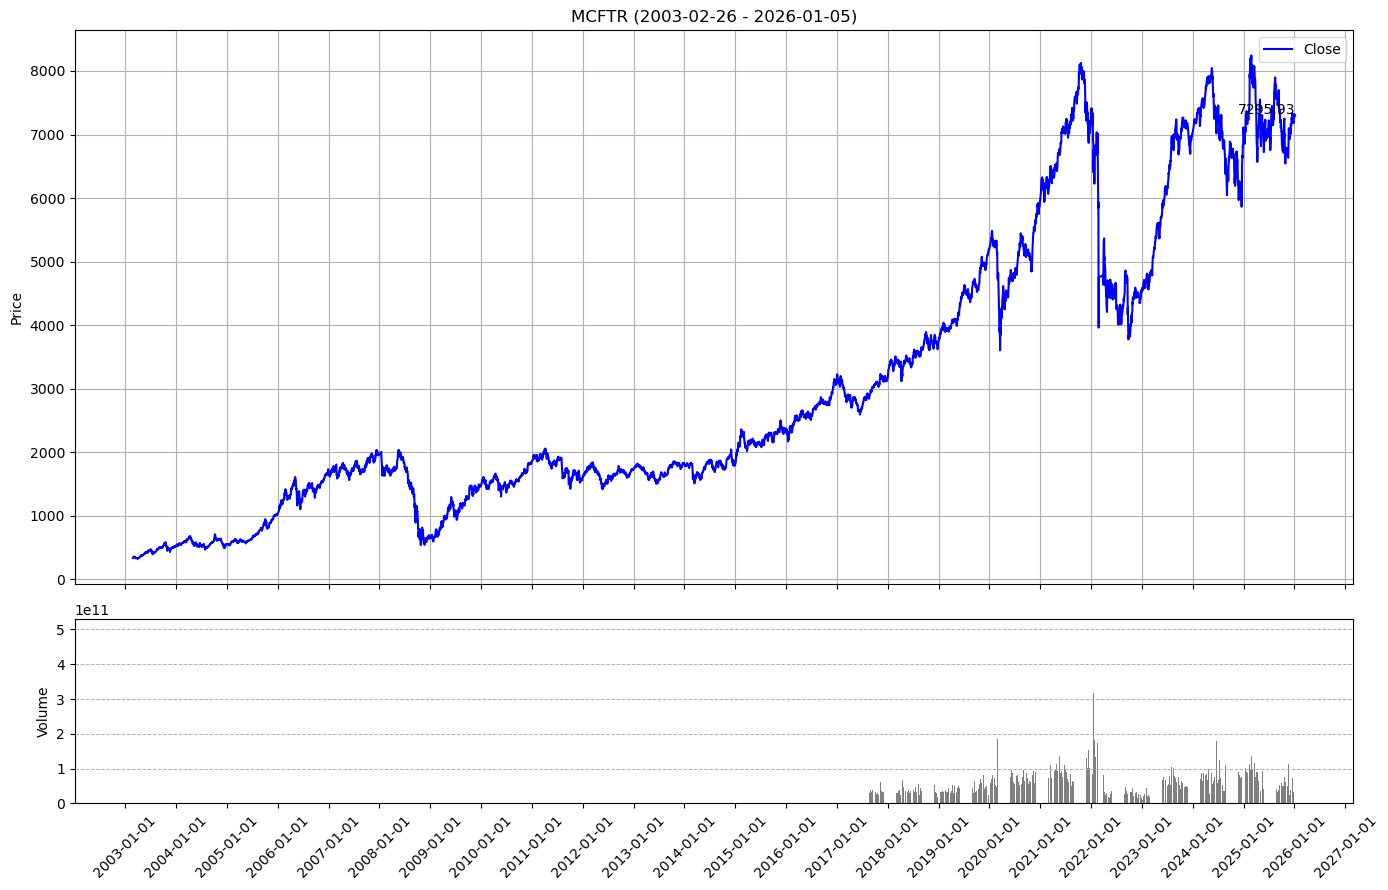

In [4]:
 # Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Candlestick representation (high-low line)
ax1.plot(df.index, df['close'], label='Close', color='blue')
ax1.set_ylabel('Price')
start_date = df.index.min().strftime('%Y-%m-%d')
end_date = df.index.max().strftime('%Y-%m-%d')
ax1.set_title(f"{ticker} ({start_date} - {end_date})")
ax1.text(df.index[-1], df['close'].iloc[-1] - 20, f'{df["close"].iloc[-1]:.2f}', 
         fontsize=10, color='black', ha='right', va='bottom')
ax1.legend()
ax1.grid()

# Volume bar plot
ax2.bar(df.index, df['volume'], width=0.8, color='gray')
ax2.set_ylabel('Volume')
ax2.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)
ax2.xaxis.set_major_locator(mdates.YearLocator())

# Formatting date on x-axis
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [5]:
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
# Средняя дневная доходность
mean_daily = df['log_return'].mean()

# Средняя годовая доходность
mean_annual = mean_daily * 250

# Стандартное отклонение (волатильность)
std_daily = df['log_return'].std()
std_annual = std_daily * np.sqrt(250)

print("Средняя годовая доходность:", mean_annual)
print("Годовое стандартное отклонение:", std_annual)

Средняя годовая доходность: 0.1345927348715755
Годовое стандартное отклонение: 0.3029798257685154
